 # CELL 1 — Imports & Load Data for LGD Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ks_2samp

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Load cleaned stratified sample from notebook 01
df = pd.read_csv('../data/cleaned_loan_data.csv')

# LGD is trained on defaulted loans only
# Non-defaulted loans have no observed recovery data
# However predictions will be generated for ALL loans in Cell 5
df_default = df[df['default'] == 1].copy()

# Load WoE maps from notebook 02 for consistent encoding
with open('../src/woe_maps.pkl', 'rb') as f:
    woe_maps = pickle.load(f)

print("Libraries imported and data loaded")
print(f"   Total loans     : {len(df):,}")
print(f"   Defaulted loans : {len(df_default):,}  <- training set")
print(f"   Non-defaulted   : {len(df) - len(df_default):,}  <- will receive LGD predictions in Cell 5")
print(f"   WoE maps loaded : {list(woe_maps.keys())}")

Libraries imported and data loaded
   Total loans     : 122,216
   Defaulted loans : 26,702  <- training set
   Non-defaulted   : 95,514  <- will receive LGD predictions in Cell 5
   WoE maps loaded : ['grade', 'sub_grade', 'home_ownership', 'verification_status']


# CELL 2 — Calculate LGD Target Variable

LGD target variable created

   Mean LGD   : 0.6223  (62.2%)
   Median LGD : 0.6636  (66.4%)
   Std Dev    : 0.2221
   Min LGD    : 0.0000
   Max LGD    : 1.0000

   LGD = 0 (full recovery) : 119 loans
   LGD = 1 (zero recovery) : 86 loans
   LGD between 0 and 1     : 26,497 loans


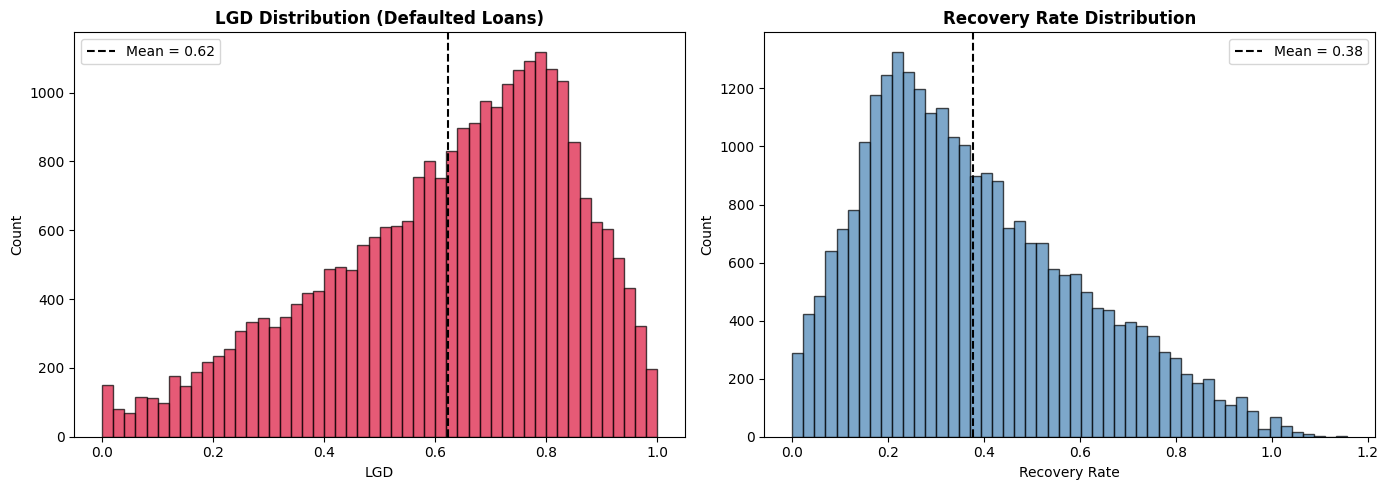

LGD distribution saved to reports/lgd_distribution.png


In [2]:
df_default['recovery_rate'] = (
    df_default['recoveries'] + df_default['total_rec_prncp']
) / df_default['funded_amnt']

df_default['lgd'] = (1 - df_default['recovery_rate']).clip(0, 1)

print("LGD target variable created")
print(f"\n   Mean LGD   : {df_default['lgd'].mean():.4f}  ({df_default['lgd'].mean()*100:.1f}%)")
print(f"   Median LGD : {df_default['lgd'].median():.4f}  ({df_default['lgd'].median()*100:.1f}%)")
print(f"   Std Dev    : {df_default['lgd'].std():.4f}")
print(f"   Min LGD    : {df_default['lgd'].min():.4f}")
print(f"   Max LGD    : {df_default['lgd'].max():.4f}")
print(f"\n   LGD = 0 (full recovery) : {(df_default['lgd'] == 0).sum():,} loans")
print(f"   LGD = 1 (zero recovery) : {(df_default['lgd'] == 1).sum():,} loans")
print(f"   LGD between 0 and 1     : {((df_default['lgd'] > 0) & (df_default['lgd'] < 1)).sum():,} loans")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_default['lgd'], bins=50, color='crimson', alpha=0.7, edgecolor='black')
axes[0].axvline(df_default['lgd'].mean(), color='black', linestyle='--',
                label=f"Mean = {df_default['lgd'].mean():.2f}")
axes[0].set_title('LGD Distribution (Defaulted Loans)', fontweight='bold')
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df_default['recovery_rate'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(df_default['recovery_rate'].mean(), color='black', linestyle='--',
                label=f"Mean = {df_default['recovery_rate'].mean():.2f}")
axes[1].set_title('Recovery Rate Distribution', fontweight='bold')
axes[1].set_xlabel('Recovery Rate')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/lgd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("LGD distribution saved to reports/lgd_distribution.png")

# Cell 3 — Feature Preparation and Model Training:

In [3]:
# --- Feature Engineering on defaulted loans ---
df_lgd = df_default.copy()

# Apply WoE encoding using maps from notebook 02
# Only encode features present in woe_maps
for col, woe_dict in woe_maps.items():
    if col in df_lgd.columns:
        df_lgd[col] = df_lgd[col].map(woe_dict)

# Engineered features — same as PD model for consistency
df_lgd['log_annual_inc'] = np.log1p(df_lgd['annual_inc'])
df_lgd['debt_burden']    = (df_lgd['installment'] / (df_lgd['annual_inc'] / 12)).clip(0, 5)

# Feature set — purpose excluded, annual_inc replaced by log_annual_inc
lgd_features = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate',
    'installment', 'grade', 'sub_grade', 'emp_length',
    'home_ownership', 'verification_status', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'fico_score',
    'credit_history_years', 'log_annual_inc', 'debt_burden'
]

df_lgd = df_lgd[lgd_features + ['lgd', 'id']].dropna()

X = df_lgd[lgd_features]
y = df_lgd['lgd']

print(f"Feature matrix prepared")
print(f"   Training samples : {len(X):,}  (defaulted loans only)")
print(f"   Features         : {X.shape[1]}")
print(f"   Features list    : {lgd_features}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Also track ids for the test set
ids_test = df_lgd.loc[y_test.index, 'id'].values

scaler_lgd = StandardScaler()
X_train_scaled = scaler_lgd.fit_transform(X_train)
X_test_scaled  = scaler_lgd.transform(X_test)

print(f"\n   Train : {X_train.shape[0]:,} rows")
print(f"   Test  : {X_test.shape[0]:,} rows")

# --- Random Forest Regressor ---
print("\nTraining Random Forest Regressor...")
rf_lgd = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rf_lgd.fit(X_train_scaled, y_train)
rf_preds = rf_lgd.predict(X_test_scaled)

# --- Gradient Boosting Regressor ---
print("Training Gradient Boosting Regressor...")
gb_lgd = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_lgd.fit(X_train_scaled, y_train)
gb_preds = gb_lgd.predict(X_test_scaled)

# --- Metrics ---
def regression_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mbe  = np.mean(y_pred - y_true)
    mask = y_true > 0.05
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"\n   {name}")
    print(f"   RMSE : {rmse:.4f}   (benchmark: <0.20 good for LGD)")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R2   : {r2:.4f}   (note: R2 < 0.30 is normal for LGD regression)")
    print(f"   MBE  : {mbe:.4f}   (+ = overestimate, - = underestimate)")
    print(f"   MAPE : {mape:.2f}%")
    return rmse, mae, r2

print("\n=== LGD MODEL RESULTS ===")
rf_rmse, rf_mae, rf_r2 = regression_metrics("Random Forest", y_test, rf_preds)
gb_rmse, gb_mae, gb_r2 = regression_metrics("Gradient Boosting", y_test, gb_preds)

best_model_name = "Random Forest" if rf_r2 >= gb_r2 else "Gradient Boosting"
best_preds      = rf_preds if rf_r2 >= gb_r2 else gb_preds
best_model      = rf_lgd  if rf_r2 >= gb_r2 else gb_lgd
best_r2         = max(rf_r2, gb_r2)

print(f"\nBest model : {best_model_name}  (R2 = {best_r2:.4f})")

Feature matrix prepared
   Training samples : 26,702  (defaulted loans only)
   Features         : 22
   Features list    : ['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'fico_score', 'credit_history_years', 'log_annual_inc', 'debt_burden']

   Train : 21,361 rows
   Test  : 5,341 rows

Training Random Forest Regressor...
Training Gradient Boosting Regressor...

=== LGD MODEL RESULTS ===

   Random Forest
   RMSE : 0.2026   (benchmark: <0.20 good for LGD)
   MAE  : 0.1615
   R2   : 0.1757   (note: R2 < 0.30 is normal for LGD regression)
   MBE  : 0.0022   (+ = overestimate, - = underestimate)
   MAPE : 42.99%

   Gradient Boosting
   RMSE : 0.2007   (benchmark: <0.20 good for LGD)
   MAE  : 0.1591
   R2   : 0.1914   (note: R2 < 0.30 is normal for LGD regression)
   MBE  : 0.0028   (+ = overe

# CELL 4 — Residual Analysis + Visualisation

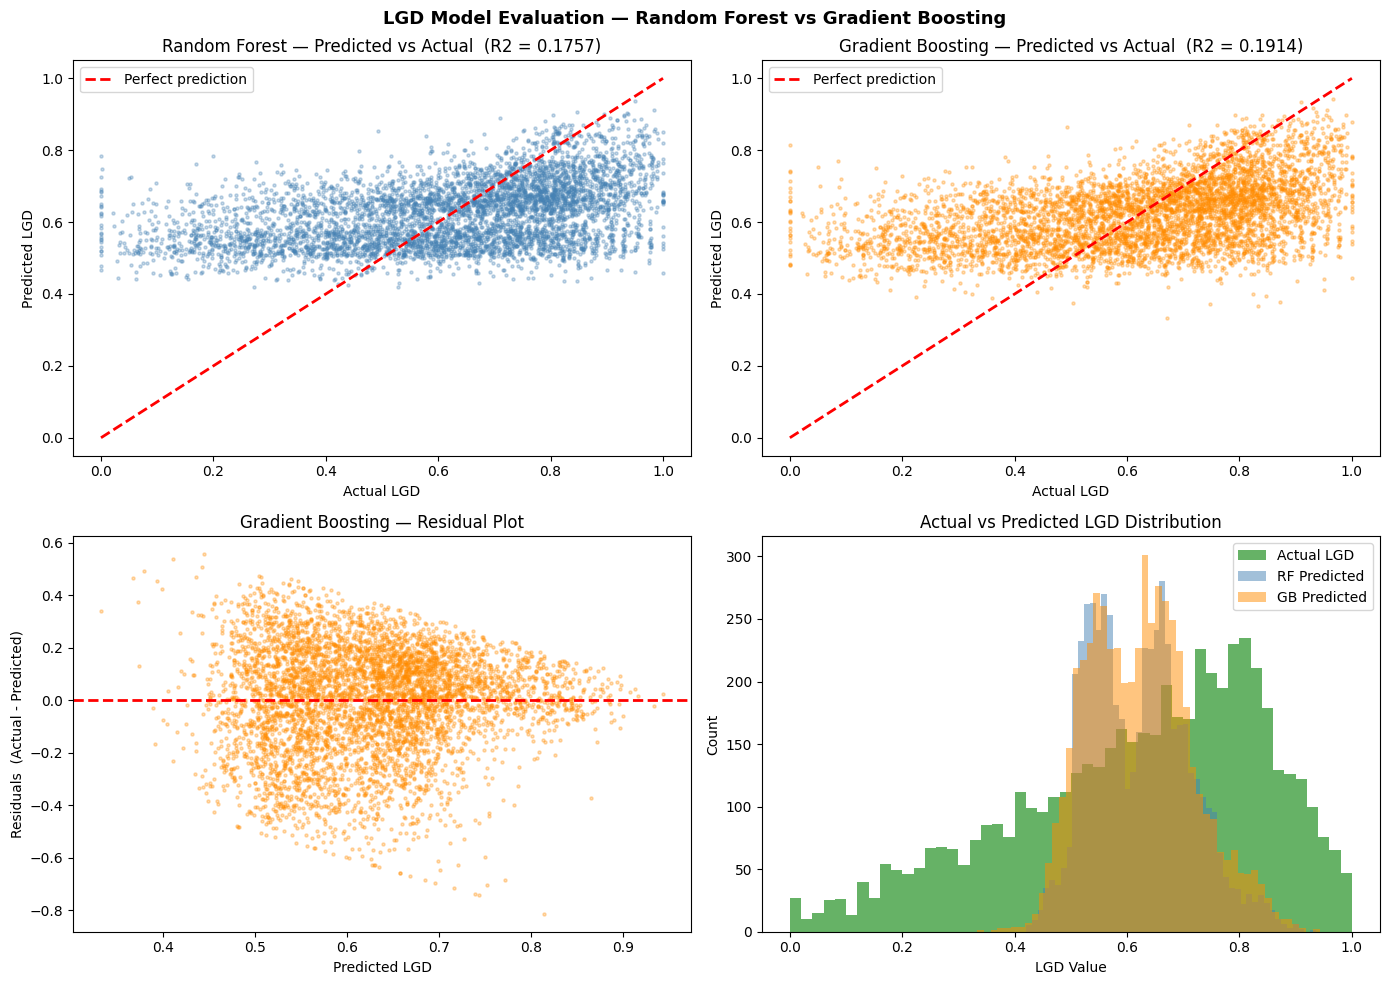

LGD evaluation plots saved to reports/lgd_evaluation.png

Winner : Gradient Boosting  (R2 = 0.1914, RMSE = 0.2007)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LGD Model Evaluation — Random Forest vs Gradient Boosting',
             fontsize=13, fontweight='bold')

# 1. Predicted vs Actual — Random Forest
axes[0, 0].scatter(y_test, rf_preds, alpha=0.3, color='steelblue', s=5)
axes[0, 0].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual LGD')
axes[0, 0].set_ylabel('Predicted LGD')
axes[0, 0].set_title(f'Random Forest — Predicted vs Actual  (R2 = {rf_r2:.4f})')
axes[0, 0].legend()

# 2. Predicted vs Actual — Gradient Boosting
axes[0, 1].scatter(y_test, gb_preds, alpha=0.3, color='darkorange', s=5)
axes[0, 1].plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect prediction')
axes[0, 1].set_xlabel('Actual LGD')
axes[0, 1].set_ylabel('Predicted LGD')
axes[0, 1].set_title(f'Gradient Boosting — Predicted vs Actual  (R2 = {gb_r2:.4f})')
axes[0, 1].legend()

# 3. Residuals — best model (GB)
gb_residuals = y_test.values - gb_preds
axes[1, 0].scatter(gb_preds, gb_residuals, alpha=0.3, color='darkorange', s=5)
axes[1, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted LGD')
axes[1, 0].set_ylabel('Residuals  (Actual - Predicted)')
axes[1, 0].set_title('Gradient Boosting — Residual Plot')

# 4. Actual vs Predicted Distribution
axes[1, 1].hist(y_test, bins=50, alpha=0.6, color='green',
                label='Actual LGD', edgecolor='none')
axes[1, 1].hist(rf_preds, bins=50, alpha=0.5, color='steelblue',
                label='RF Predicted', edgecolor='none')
axes[1, 1].hist(gb_preds, bins=50, alpha=0.5, color='darkorange',
                label='GB Predicted', edgecolor='none')
axes[1, 1].set_xlabel('LGD Value')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Actual vs Predicted LGD Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../reports/lgd_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("LGD evaluation plots saved to reports/lgd_evaluation.png")
print(f"\nWinner : {best_model_name}  (R2 = {best_r2:.4f}, RMSE = {gb_rmse:.4f})")

# CELL 5 — Save LGD Model & Predictions

In [5]:
# --- 1. Prepare full portfolio feature matrix ---
df_full = df.copy()

# Apply same WoE encoding as training
for col, woe_dict in woe_maps.items():
    if col in df_full.columns:
        df_full[col] = df_full[col].map(woe_dict)

# Same engineered features
df_full['log_annual_inc'] = np.log1p(df_full['annual_inc'])
df_full['debt_burden']    = (df_full['installment'] / (df_full['annual_inc'] / 12)).clip(0, 5)

# Select same feature set used in training
df_full_lgd = df_full[lgd_features + ['id']].copy()

# Handle any NaN rows — fill with median from training set
for col in lgd_features:
    median_val = X_train[col].median()
    df_full_lgd[col] = df_full_lgd[col].fillna(median_val)

# Scale using the same scaler fitted on training data
X_full_scaled = scaler_lgd.transform(df_full_lgd[lgd_features])

# --- 2. Generate predictions for all loans ---
lgd_all_predicted = best_model.predict(X_full_scaled).clip(0, 1)

# --- 3. Build results dataframe ---
lgd_results_full = pd.DataFrame({
    'id'            : df_full_lgd['id'].values,
    'lgd_predicted' : lgd_all_predicted
})

# Also save test set predictions separately for model evaluation reference
lgd_results_test = pd.DataFrame({
    'id'            : ids_test,
    'actual_lgd'    : y_test.values,
    'lgd_predicted' : best_preds.clip(0, 1)
})

# --- 4. Save model artifacts ---
joblib.dump(best_model,  '../src/lgd_model.pkl')
joblib.dump(scaler_lgd,  '../src/scaler_lgd.pkl')

lgd_results_full.to_csv('../data/lgd_predictions.csv', index=False)
lgd_results_test.to_csv('../data/lgd_predictions_test.csv', index=False)

# --- 5. Diagnostics ---
print("LGD Model saved and predictions generated")
print(f"\n   Model              : {best_model_name}")
print(f"   R2                 : {best_r2:.4f}")
print(f"   RMSE               : {gb_rmse:.4f}")
print(f"\n   Predictions saved  : {len(lgd_results_full):,} loans  (full portfolio)")
print(f"   Test set saved     : {len(lgd_results_test):,} loans  (evaluation reference)")
print(f"\n   Mean predicted LGD (defaulted loans)     : "
      f"{lgd_all_predicted[df['default'] == 1].mean():.4f}  "
      f"({lgd_all_predicted[df['default'] == 1].mean()*100:.1f}%)")
print(f"   Mean predicted LGD (non-defaulted loans) : "
      f"{lgd_all_predicted[df['default'] == 0].mean():.4f}  "
      f"({lgd_all_predicted[df['default'] == 0].mean()*100:.1f}%)")
print(f"   Mean predicted LGD (full portfolio)      : "
      f"{lgd_all_predicted.mean():.4f}  "
      f"({lgd_all_predicted.mean()*100:.1f}%)")
print(f"\n   Files saved:")
print(f"   src/lgd_model.pkl              — {best_model_name}")
print(f"   src/scaler_lgd.pkl             — StandardScaler")
print(f"   data/lgd_predictions.csv       — full portfolio ({len(lgd_results_full):,} rows)")
print(f"   data/lgd_predictions_test.csv  — test set evaluation ({len(lgd_results_test):,} rows)")

LGD Model saved and predictions generated

   Model              : Gradient Boosting
   R2                 : 0.1914
   RMSE               : 0.2007

   Predictions saved  : 122,216 loans  (full portfolio)
   Test set saved     : 5,341 loans  (evaluation reference)

   Mean predicted LGD (defaulted loans)     : 0.6228  (62.3%)
   Mean predicted LGD (non-defaulted loans) : 0.5716  (57.2%)
   Mean predicted LGD (full portfolio)      : 0.5828  (58.3%)

   Files saved:
   src/lgd_model.pkl              — Gradient Boosting
   src/scaler_lgd.pkl             — StandardScaler
   data/lgd_predictions.csv       — full portfolio (122,216 rows)
   data/lgd_predictions_test.csv  — test set evaluation (5,341 rows)
